In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [35]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [6]:
!pip install pandas numpy

In [8]:
!pip install pandas numpy matplotlib scipy scikit-learn

In [98]:
df = pd.read_csv('encuesta_salud.csv')

In [41]:
df

,id,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa,grupo_sanguineo,region,diagnostico
0,1,56.00,86.80,1.80,124.80,231.00,77.50,B-,Araucania,Sano
1,2,69.00,72.70,1.46,104.40,148.90,102.50,A+,Biobio,Hipertension
2,3,46.00,84.20,1.50,164.50,220.30,78.30,AB+,Valparaiso,Hipertension
3,4,32.00,86.90,1.63,95.20,218.40,60.50,AB-,Araucania,Prediabetes
4,5,NaN,58.60,1.78,130.50,152.60,400.00,B-,Biobio,Sano
...,...,...,...,...,...,...,...,...,...,...
495,496,63.00,NaN,1.61,135.60,220.00,118.70,A-,Araucania,Hipertension
496,497,41.00,90.40,1.76,147.50,189.60,66.10,NaN,Araucania,Prediabetes
497,498,67.00,47.50,1.62,140.30,164.40,114.10,NaN,OHiggins,Hipertension
498,499,49.00,82.60,186.00,81.30,194.30,103.90,A+,Araucania,Sano


In [11]:
df.info

<bound method DataFrame.info of       id  edad  peso_kg  talla_m  presion_arterial  colesterol  glucosa  \
0      1 56.00    86.80     1.80            124.80      231.00    77.50   
1      2 69.00    72.70     1.46            104.40      148.90   102.50   
2      3 46.00    84.20     1.50            164.50      220.30    78.30   
3      4 32.00    86.90     1.63             95.20      218.40    60.50   
4      5   NaN    58.60     1.78            130.50      152.60   400.00   
..   ...   ...      ...      ...               ...         ...      ...   
495  496 63.00      NaN     1.61            135.60      220.00   118.70   
496  497 41.00    90.40     1.76            147.50      189.60    66.10   
497  498 67.00    47.50     1.62            140.30      164.40   114.10   
498  499 49.00    82.60   186.00             81.30      194.30   103.90   
499  500 64.00      NaN   160.00            122.50      178.00    72.50   

    grupo_sanguineo      region   diagnostico  
0                B-

In [13]:
print(df.describe())

          id   edad  peso_kg  talla_m  presion_arterial  colesterol  glucosa
count 500.00 455.00   440.00   500.00            500.00      460.00   500.00
mean  250.50  50.18    72.44     6.76            123.15      193.66   101.81
std   144.48  18.21    14.32    28.92             29.66       34.47    47.26
min     1.00  18.00    34.80     1.33             62.20      102.60    18.60
25%   125.75  35.00    63.27     1.61            106.35      170.15    80.38
50%   250.50  50.00    72.35     1.69            120.75      193.95    97.45
75%   375.25  66.00    82.93     1.75            133.68      217.05   112.80
max   500.00  79.00   111.00   186.00            290.00      290.60   420.00


In [42]:
print(df.isnull().sum())

id                   0
edad                45
peso_kg             60
talla_m              0
presion_arterial     0
colesterol          40
glucosa              0
grupo_sanguineo     25
region               0
diagnostico         30
dtype: int64


In [15]:
print(f"Mínimo: {df['talla_m'].min()} | Máximo: {df['talla_m'].max()}")

Mínimo: 1.33 | Máximo: 186.0


In [17]:
df.shape

(500, 10)

In [43]:
print(df.isnull().sum())

id                   0
edad                45
peso_kg             60
talla_m              0
presion_arterial     0
colesterol          40
glucosa              0
grupo_sanguineo     25
region               0
diagnostico         30
dtype: int64


In [19]:
print(df)

      id  edad  peso_kg  talla_m  presion_arterial  colesterol  glucosa  \
0      1 56.00    86.80     1.80            124.80      231.00    77.50   
1      2 69.00    72.70     1.46            104.40      148.90   102.50   
2      3 46.00    84.20     1.50            164.50      220.30    78.30   
3      4 32.00    86.90     1.63             95.20      218.40    60.50   
4      5   NaN    58.60     1.78            130.50      152.60   400.00   
..   ...   ...      ...      ...               ...         ...      ...   
495  496 63.00      NaN     1.61            135.60      220.00   118.70   
496  497 41.00    90.40     1.76            147.50      189.60    66.10   
497  498 67.00    47.50     1.62            140.30      164.40   114.10   
498  499 49.00    82.60   186.00             81.30      194.30   103.90   
499  500 64.00      NaN   160.00            122.50      178.00    72.50   

    grupo_sanguineo      region   diagnostico  
0                B-   Araucania          Sano  
1  

#Observaciones sobre el primer ejercicio 1.
#Filas y columnas: Cuenta con 500 filas y 10 columnas
#Hay datos desde objets, numericos [int64] y floats
#Las columnas edad, peso_kg, colesterol, grupo_sanguineo y diagnostico. Presentan datos NaN
#Los datos presentes en talla con datos desde 186 metros, 160 metros. siendo valores extraños o atípicos.
#Debido a que la muestra abarca desde 1.33 metros a 186 metros, lo que indica que fueron ingresados como cm en vez de metros.

In [44]:
#Ejercicio 2.
talla=df.loc[df['talla_m'] > 3, 'talla_m'] = df['talla_m'] / 100
print(talla)

0     0.02
1     0.01
2     0.01
3     0.02
4     0.02
      ... 
495   0.02
496   0.02
497   0.02
498   1.86
499   1.60
Name: talla_m, Length: 500, dtype: float64


In [100]:
# 2.
for col in df.select_dtypes(include=['number']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [101]:
print(df.isnull().sum())

id                  0
edad                0
peso_kg             0
talla_m             0
presion_arterial    0
colesterol          0
glucosa             0
grupo_sanguineo     0
region              0
diagnostico         0
dtype: int64


<Axes: >

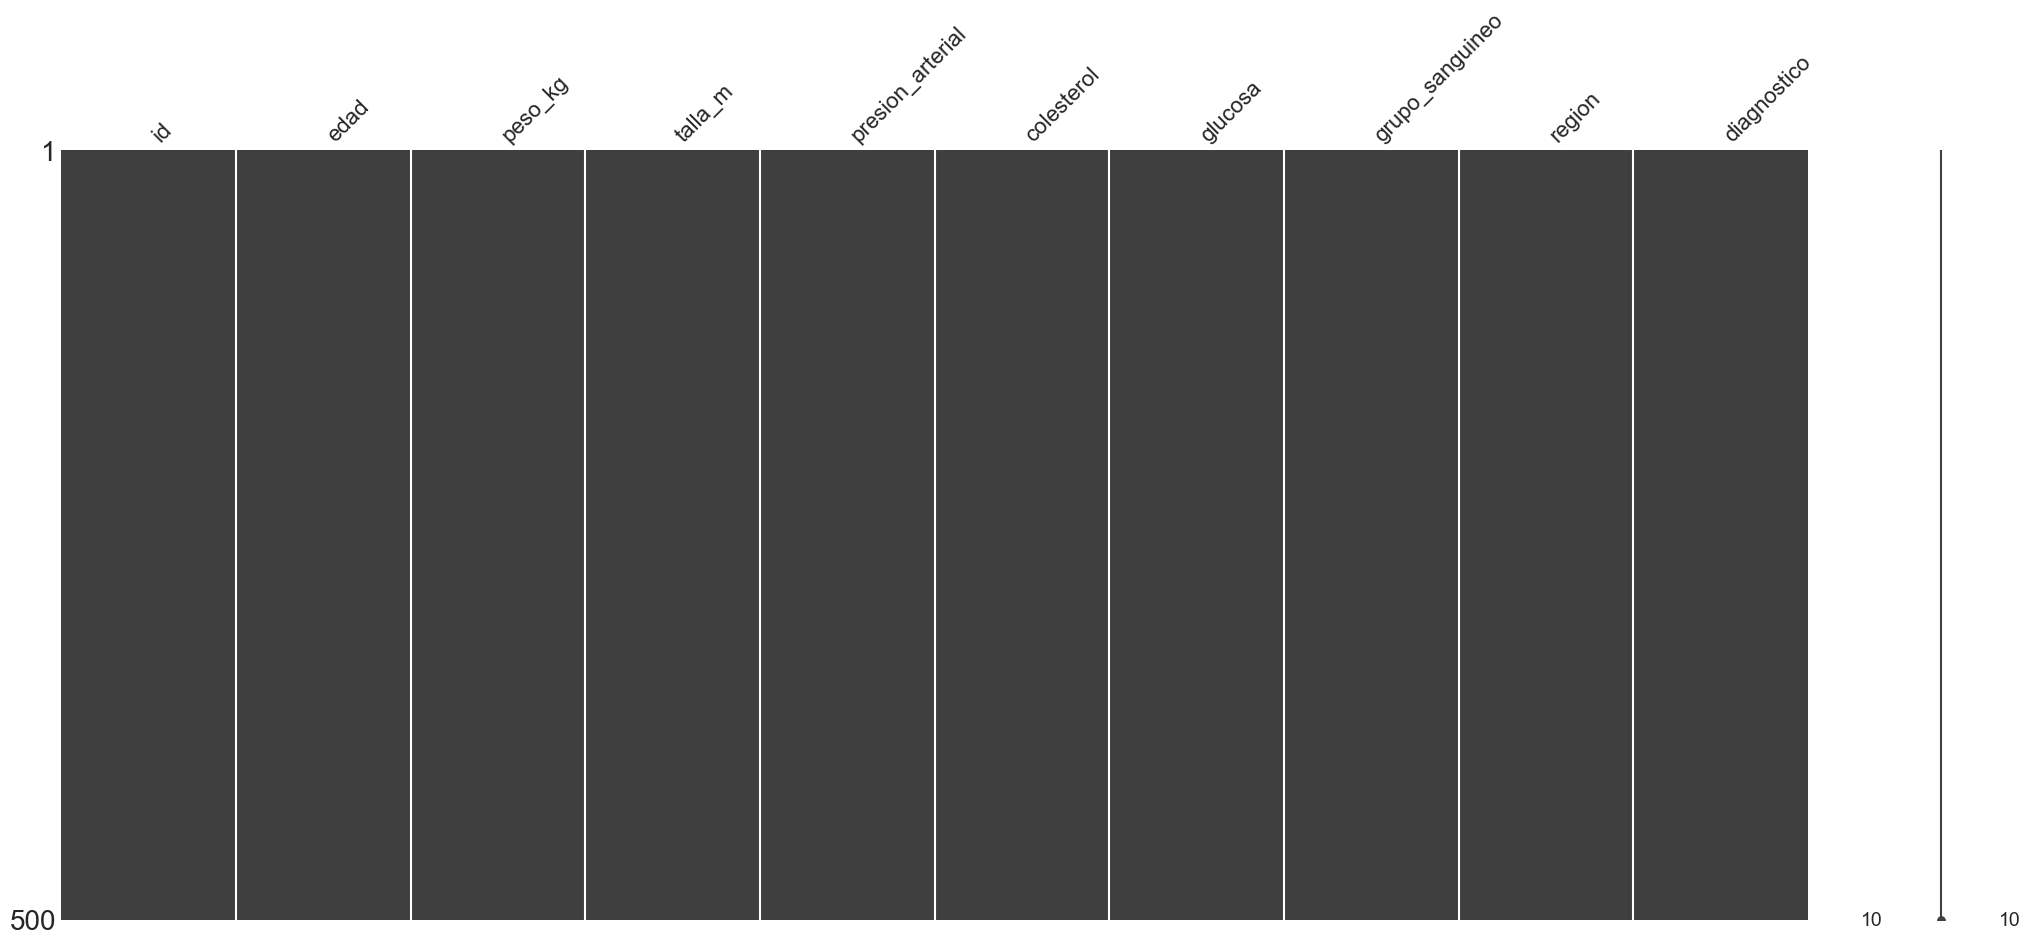

In [102]:
import missingno as msno
msno.matrix(df)

In [103]:
print("Valores nulos restantes:", df.isnull().sum().sum())

Valores nulos restantes: 0


#Documenta en una celda Markdown: que columnas tenían NaN, que estrategia usaste y por qué.
#Como mencionamos las columnas edad, peso_kg, colesterol, grupo_sanguineo y diagnostico poseen datos NaN.
#Se reemplazan los datos tanto por la mediana y la moda para no afectar tantos los resultados del dataframe.
#Porque de ser así de eliminarían muchos datos con otras estrategias de limpieza de datos.

In [104]:
#Ejercicio 3.
q1 = df['presion_arterial'].quantile(0.25)
q3 = df['presion_arterial'].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

In [105]:
outliers = df[(df['presion_arterial'] < lim_inf) | (df['presion_arterial'] > lim_sup)]
print(f'Outliers detectados en presion_arterial: {len(outliers)}')

Outliers detectados en presion_arterial: 15


In [106]:
df_limpio = df[(df['presion_arterial'] >= lim_inf) & (df['presion_arterial'] <= lim_sup)].copy()

In [107]:
z_scores = np.abs(stats.zscore(df_limpio['glucosa']))
outliers_z = df_limpio[z_scores > 3]
print(f'Outliers por Z-Score en glucosa (|z| > 3): {len(outliers_z)}')

Outliers por Z-Score en glucosa (|z| > 3): 10


In [108]:
df_limpio = df_limpio[z_scores <= 3].copy()

Text(0, 0.5, 'mmHg')

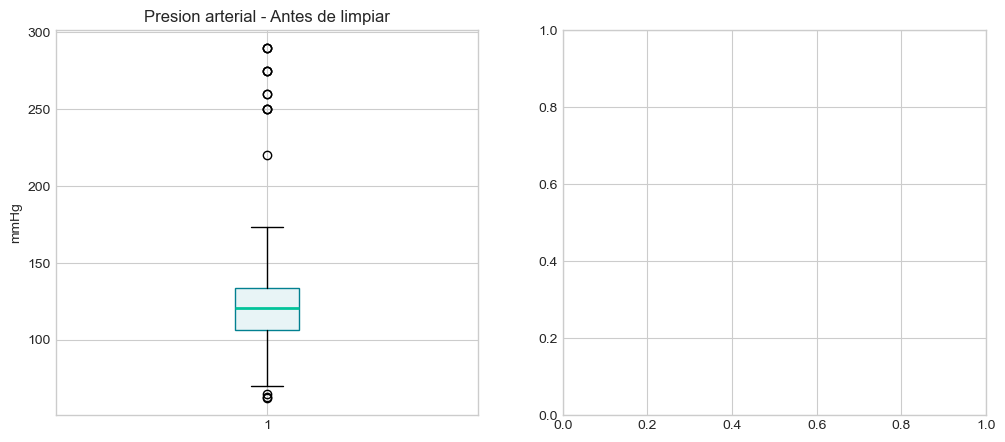

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Antes de limpiar
axes[0].boxplot(df['presion_arterial'], vert=True, patch_artist=True,
 boxprops=dict(facecolor='#E8F4F6', color='#028090'),
 medianprops=dict(color='#02C39A', linewidth=2))
axes[0].set_title('Presion arterial - Antes de limpiar')
axes[0].set_ylabel('mmHg')

In [90]:
df_limpio = df[(df['presion_arterial'] >= lim_inf) & (df['presion_arterial'] <= lim_sup)]

In [93]:
# Despues de limpiar
axes[1].boxplot(df_limpio['presion_arterial'], vert=True, patch_artist=True,
 boxprops=dict(facecolor='#E8F4F6', color='#028090'),
 medianprops=dict(color='#02C39A', linewidth=2))
axes[1].set_title('Presion arterial - Sin outliers')
axes[1].set_ylabel('mmHg')
plt.suptitle('Deteccion de Outliers con Metodo IQR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_presion.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [92]:
df = df_limpio.copy()
print(f'Filas restantes tras eliminar outliers: {len(df)}')

Filas restantes tras eliminar outliers: 485


Text(0, 0.5, 'mmHg')

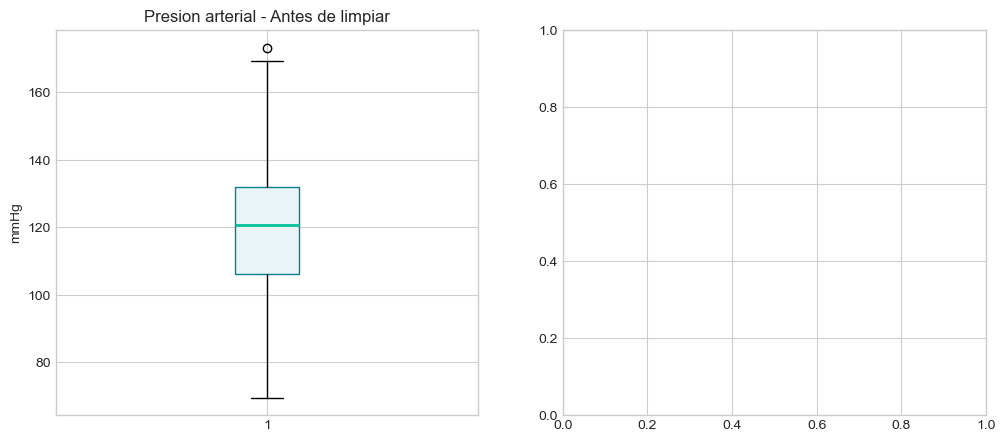

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Antes de limpiar
axes[0].boxplot(df['presion_arterial'], vert=True, patch_artist=True,
 boxprops=dict(facecolor='#E8F4F6', color='#028090'),
 medianprops=dict(color='#02C39A', linewidth=2))
axes[0].set_title('Presion arterial - Antes de limpiar')
axes[0].set_ylabel('mmHg')

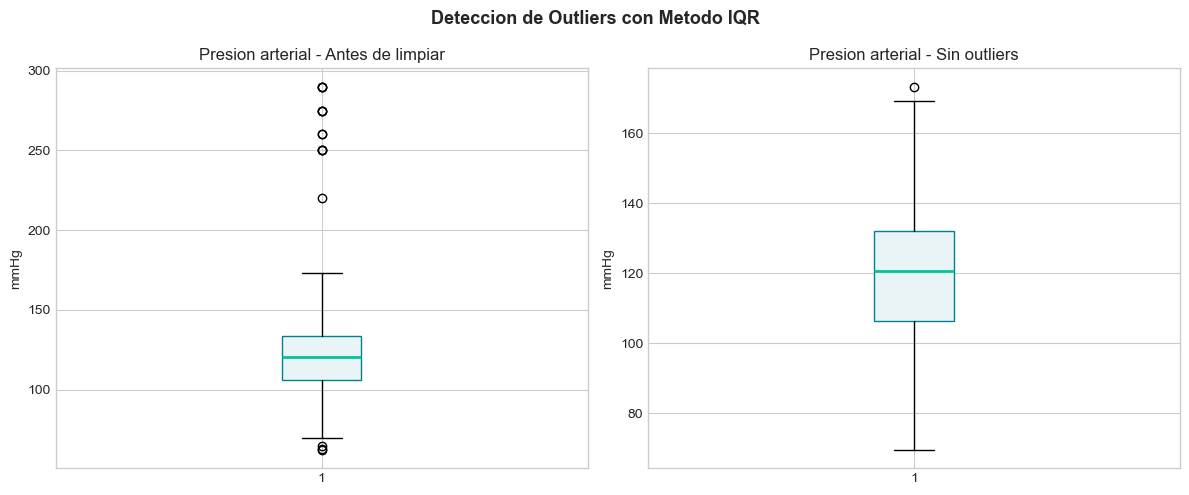

Filas restantes tras eliminar outliers: 485


In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Antes de limpiar
axes[0].boxplot(df['presion_arterial'], vert=True, patch_artist=True,
 boxprops=dict(facecolor='#E8F4F6', color='#028090'),
 medianprops=dict(color='#02C39A', linewidth=2))
axes[0].set_title('Presion arterial - Antes de limpiar')
axes[0].set_ylabel('mmHg')
# Filtrar outliers
df_limpio = df[(df['presion_arterial'] >= lim_inf) & (df['presion_arterial'] <= lim_sup)]
# Despues de limpiar
axes[1].boxplot(df_limpio['presion_arterial'], vert=True, patch_artist=True,
 boxprops=dict(facecolor='#E8F4F6', color='#028090'),
 medianprops=dict(color='#02C39A', linewidth=2))
axes[1].set_title('Presion arterial - Sin outliers')
axes[1].set_ylabel('mmHg')
plt.suptitle('Deteccion de Outliers con Metodo IQR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_presion.png', dpi=150, bbox_inches='tight')
plt.show()
# Actualizar DataFrame principal
df = df_limpio.copy()
print(f'Filas restantes tras eliminar outliers: {len(df)}')


Dependería realmente, si son valores atipicos demasiado anormales para lo que se presenta, yo creo que si.
Si es un valor en verdad fuera de lo comun pero que respecta bajo el marco de la salud humana posible, si debería dejarse en mi opinión.

In [119]:
#Ejercicio 4
# Seleccionar columnas numericas a normalizar
cols_numericas = ['edad', 'peso_kg', 'talla_m', 'presion_arterial', 'colesterol', 'glucosa']
# Min-Max Scaling
scaler_mm = MinMaxScaler()
# scaler_mm.fit_transform(df[cols_numericas])
print('Estadisticas tras Min-Max Scaling:')
print(df_minmax[cols_numericas].describe().round(3))

Estadisticas tras Min-Max Scaling:
        edad  peso_kg  talla_m  presion_arterial  colesterol  glucosa
count 485.00   485.00   485.00            485.00      485.00   485.00
mean    0.53     0.49     0.03              0.49        0.48     0.21
std     0.28     0.18     0.15              0.18        0.17     0.12
min     0.00     0.00     0.00              0.00        0.00     0.00
25%     0.33     0.40     0.00              0.35        0.37     0.15
50%     0.53     0.49     0.00              0.49        0.49     0.20
75%     0.77     0.61     0.00              0.60        0.59     0.23
max     1.00     1.00     1.00              1.00        1.00     1.00


In [115]:
#Ejercicio 4
cols_numericas = ['edad', 'peso_kg', 'talla_m', 'presion_arterial', 'colesterol', 'glucosa']
scaler_mm = MinMaxScaler()

df_minmax = df_limpio.copy()
df_minmax[cols_numericas] = scaler_mm.fit_transform(df_minmax[cols_numericas])

print("Estadísticas tras Min-Max Scaling (min y max deben ser 0 y 1):")
display(df_minmax[cols_numericas].describe().round(3).loc[['min', 'max']])

Estadísticas tras Min-Max Scaling (min y max deben ser 0 y 1):


,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa
min,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00


In [122]:
#Ejercicio 5
# Trabajar sobre copia del DataFrame normalizado
df_final = df_minmax.copy()
# One-Hot Encoding para 'region'
df_final = pd.get_dummies('region')
# One-Hot Encoding para 'grupo_sanguineo'
df_final = pd.get_dummies('grupo_sanguineo')
print('Columnas nuevas generadas:')
nuevas_cols = [c for c in df_final.columns if 'region_' in c or 'grupo_' in c]
print(nuevas_cols)
print(f'\nDimensiones del DataFrame final: {df_final.shape}')

Columnas nuevas generadas:
['grupo_sanguineo']

Dimensiones del DataFrame final: (1, 1)


In [123]:
df

,id,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa,grupo_sanguineo,region,diagnostico
0,1,56.00,86.80,1.80,124.80,231.00,77.50,B-,Araucania,Sano
1,2,69.00,72.70,1.46,104.40,148.90,102.50,A+,Biobio,Hipertension
2,3,46.00,84.20,1.50,164.50,220.30,78.30,AB+,Valparaiso,Hipertension
3,4,32.00,86.90,1.63,95.20,218.40,60.50,AB-,Araucania,Prediabetes
4,5,50.00,58.60,1.78,130.50,152.60,400.00,B-,Biobio,Sano
...,...,...,...,...,...,...,...,...,...,...
495,496,63.00,72.35,1.61,135.60,220.00,118.70,A-,Araucania,Hipertension
496,497,41.00,90.40,1.76,147.50,189.60,66.10,AB-,Araucania,Prediabetes
497,498,67.00,47.50,1.62,140.30,164.40,114.10,AB-,OHiggins,Hipertension
498,499,49.00,82.60,186.00,81.30,194.30,103.90,A+,Araucania,Sano


<Axes: >

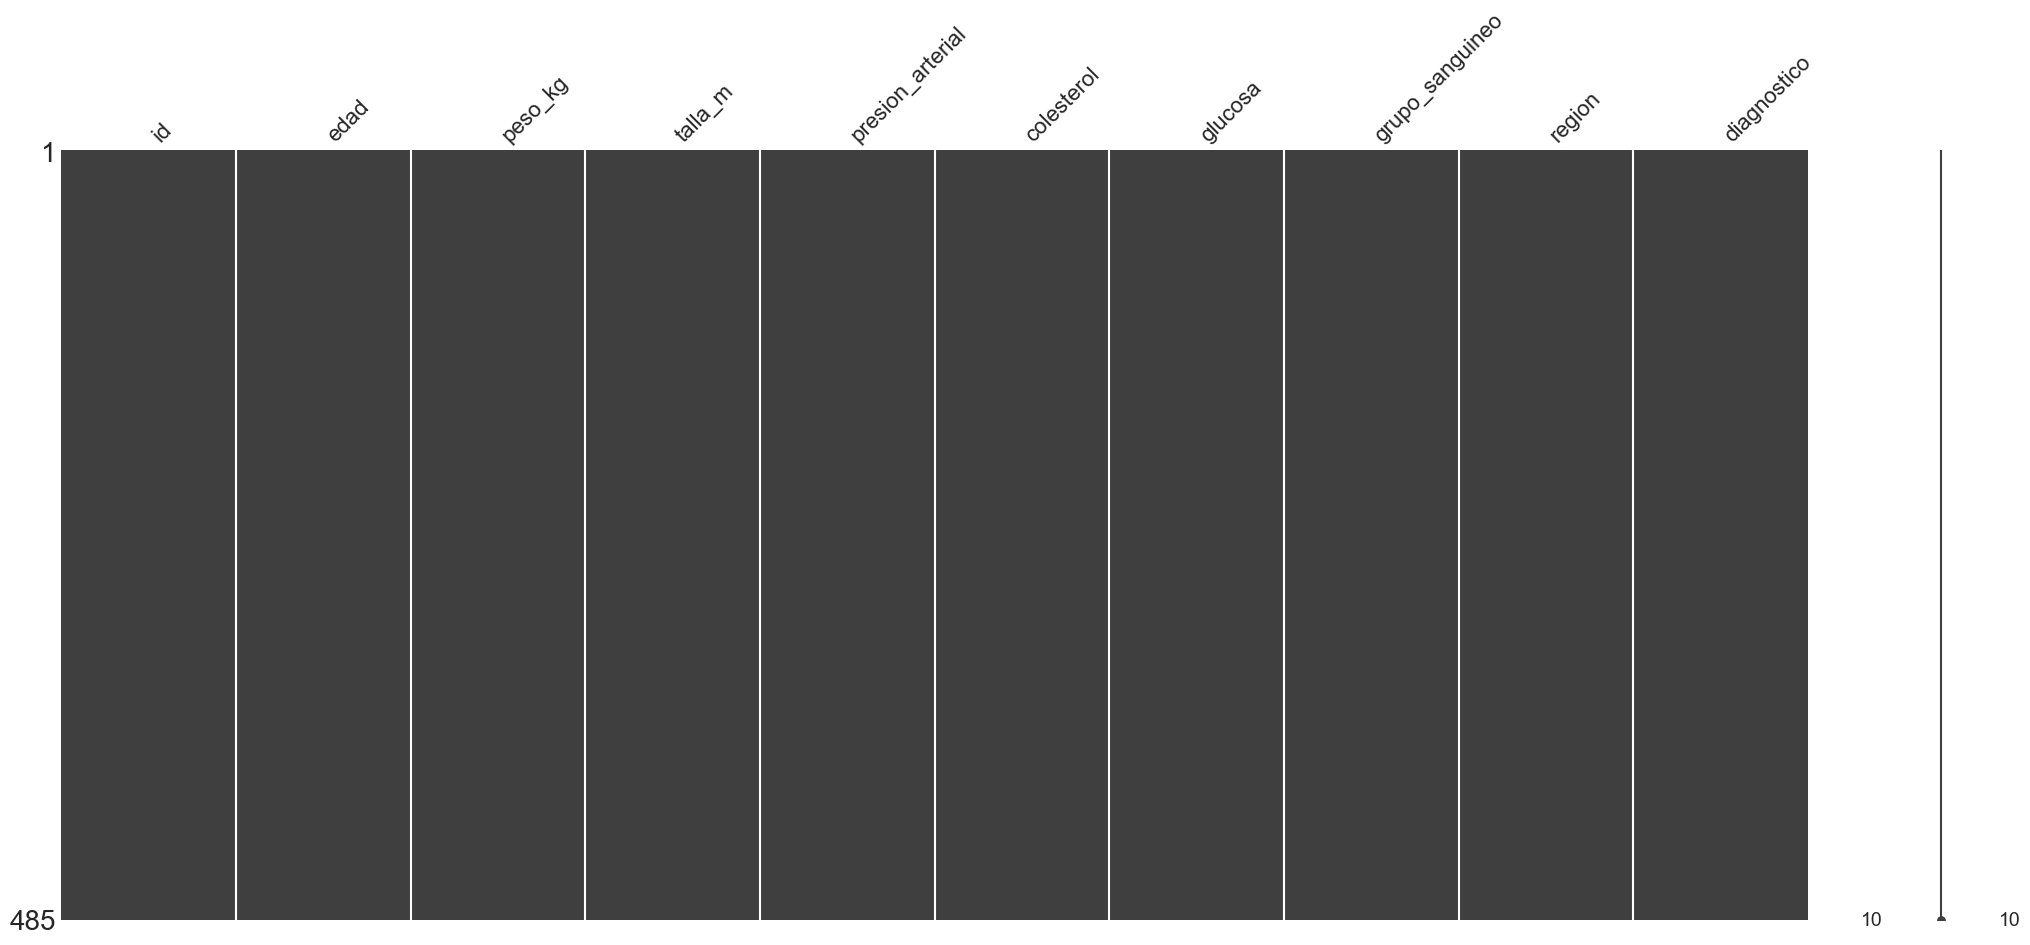

In [125]:
msno.matrix(df)

In [143]:
#Ejercicio 5
# Trabajar sobre copia del DataFrame normalizado
df_final = df_minmax.copy()
# One-Hot Encoding para 'region'
df_final = pd.get_dummies('region')
# One-Hot Encoding para 'grupo_sanguineo'
df_final = pd.get_dummies('grupo_sanguineo')
print('Columnas nuevas generadas:')
nuevas_cols = [c for c in df_final.columns if 'region_' in c or 'grupo_' in c]
print(nuevas_cols)
print(f'\nDimensiones del DataFrame final: {df_final.shape}')

Columnas nuevas generadas:
['grupo_sanguineo']

Dimensiones del DataFrame final: (1, 1)


In [144]:
df_final = df_minmax.copy()

df_final = pd.get_dummies(df_final, columns=['region', 'grupo_sanguineo'], drop_first=True)

le = LabelEncoder()
df_final['diagnostico_cod'] = le.fit_transform(df_final['diagnostico'])

mapeo = dict(zip(le.classes_, le.transform(le.classes_)))
print('Mapeo label:', mapeo)

print(f"Dimensiones iniciales del dataset: {df.shape}")
print(f"Dimensiones finales del DataFrame: {df_final.shape}")

Mapeo label: {'Diabetes': 0, 'Hipertension': 1, 'Obesidad': 2, 'Prediabetes': 3, 'Sano': 4}
Dimensiones iniciales del dataset: (485, 10)
Dimensiones finales del DataFrame: (485, 20)


Poseía al principio 10 columnas y 485 filas.
Al final quedó con 20 columnas y 485 filas.

In [148]:
print('='*60)
print('RESUMEN DEL PIPELINE DE LIMPIEZA ENCUESTA SALUD')
print('='*60)
print(f'Filas originales: 500')
print(f'Filas finales: {len(df_final)}')
print(f'Columnas originales: 10')
print(f'Columnas finales: {len(df_final.columns)}')
print(f'Valores NaN restantes: {df_final.isnull().sum().sum()}')

df_final.to_csv('encuesta_salud_limpio.csv', index=False)
print('\nDataset limpio guardado como encuesta_salud_limpio.csv')

RESUMEN DEL PIPELINE DE LIMPIEZA ENCUESTA SALUD
Filas originales: 500
Filas finales: 485
Columnas originales: 10
Columnas finales: 20
Valores NaN restantes: 0

Dataset limpio guardado como encuesta_salud_limpio.csv
